# Análisis de Experimento A/A/B para una Aplicación de Ventas 

## Descripción del proyecto
Trabajas en una empresa emergente que vende productos alimenticios. Debes investigar el comportamiento del usuario para la aplicación de la empresa.

Primero, estudia el embudo de ventas. Descubre cómo los usuarios llegan a la etapa de compra. ¿Cuántos usuarios realmente llegan a esta etapa? ¿Cuántos se atascan en etapas anteriores? ¿Qué etapas en particular?

Luego, observa los resultados de un test A/A/B (sigue leyendo para obtener más información sobre los test A/A/B). Al equipo de diseño le gustaría cambiar las fuentes de toda la aplicación, pero la gerencia teme que los usuarios piensen que el nuevo diseño es intimidante. Por ello, deciden tomar una decisión basada en los resultados de un test A/A/B.

Los usuarios se dividen en tres grupos: dos grupos de control obtienen las fuentes antiguas y un grupo de prueba obtiene las nuevas. Descubre qué conjunto de fuentes produce mejores resultados.

Crear dos grupos A tiene ciertas ventajas. Podemos establecer el principio de que solo confiaremos en la exactitud de nuestras pruebas cuando los dos grupos de control sean similares. Si hay diferencias significativas entre los grupos A, esto puede ayudarnos a descubrir factores que pueden estar distorsionando los resultados. La comparación de grupos de control también nos dice cuánto tiempo y datos necesitaremos cuando realicemos más tests.

Utilizarás el mismo dataset para el análisis general y para el análisis A/A/B. En proyectos reales, los experimentos se llevan a cabo constantemente. El equipo de análisis estudia la calidad de una aplicación utilizando datos generales, sin prestar atención a si los usuarios participan en experimentos.

## Descripción de los datos
Cada entrada de registro es una acción de usuario o un evento.

-EventName: nombre del evento.

-DeviceIDHash: identificador de usuario unívoco.

-EventTimestamp: hora del evento.

-ExpId: número de experimento. 246 y 247 son los grupos de control, y 248 es el grupo de prueba.

### Paso 1. Abrir el archivo de datos y leer la información general

In [1]:
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import numpy as np
pd.set_option('display.max_columns', None)

In [2]:
empresa = pd.read_csv('/datasets/logs_exp_us.csv', sep= '\t')
empresa.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


### Paso 2. Preparar los datos para el análisis

In [3]:
empresa.columns= ['event', 'userid', 'date', 'exp_id']
empresa.head()

,event,userid,date,exp_id
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [4]:
empresa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   event   244126 non-null  object
 1   userid  244126 non-null  int64 
 2   date    244126 non-null  int64 
 3   exp_id  244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [5]:
empresa['date'] = pd.to_datetime(empresa['date'],  unit='s')
empresa.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   event   244126 non-null  object        
 1   userid  244126 non-null  int64         
 2   date    244126 non-null  datetime64[ns]
 3   exp_id  244126 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 7.5+ MB


In [6]:
empresa['dates'] = pd.to_datetime(empresa['date']).dt.normalize()

In [7]:
empresa.head()

,event,userid,date,exp_id,dates
0,MainScreenAppear,4575588528974610257,2019-07-25 04:43:36,246,2019-07-25
1,MainScreenAppear,7416695313311560658,2019-07-25 11:11:42,246,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
3,CartScreenAppear,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,2019-07-25 11:48:42,248,2019-07-25


### Paso 3. Estudiar y comprobar los datos

In [8]:
sumreg= empresa['event'].count()
sumreg

244126

In [9]:
sumuser= empresa['userid'].count()
sumuser

244126

In [10]:
mean_event_user = empresa.groupby('userid').size().mean()
print(f'{mean_event_user:.3f}')

32.330


In [11]:
empresa['date'].min(), empresa['date'].max()

(Timestamp('2019-07-25 04:43:36'), Timestamp('2019-08-07 21:15:17'))

In [12]:
event_by_day= empresa.groupby('dates').agg(
    events=('event','count'),
    users= ('userid','nunique')
).reset_index()


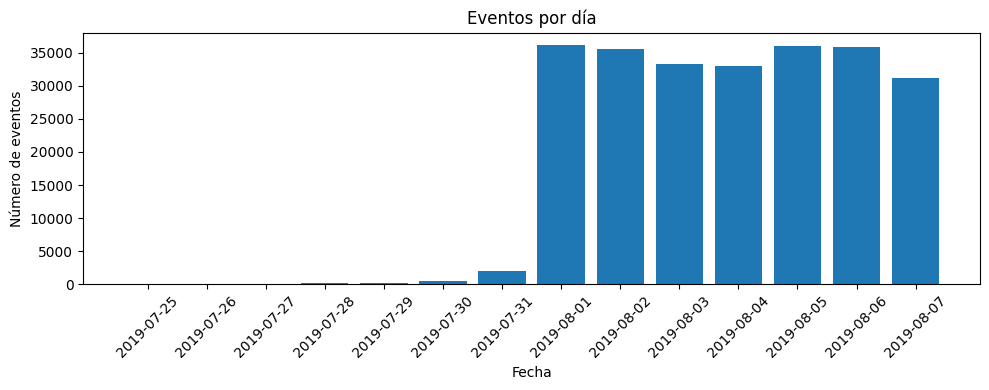

In [13]:
#Histograma de Eventos por día
plt.figure(figsize=(10,4))
plt.bar(event_by_day['dates'].astype(str), event_by_day['events'])
plt.xticks(rotation=45)
plt.title("Eventos por día")
plt.xlabel("Fecha")
plt.ylabel("Número de eventos")
plt.tight_layout()
plt.show()

Conclusión: Aunque los datos originales cubren del 25 de julio al 7 de agosto de 2019, se observa que antes del 1 de agosto el número de eventos y usuarios es muy bajo, lo que indica que los datos no están completos.

Por lo tanto, se decidió ignorar los registros anteriores al 1 de agosto.

El periodo real que representan los datos es del 1 de agosto al 7 de agosto de 2019.


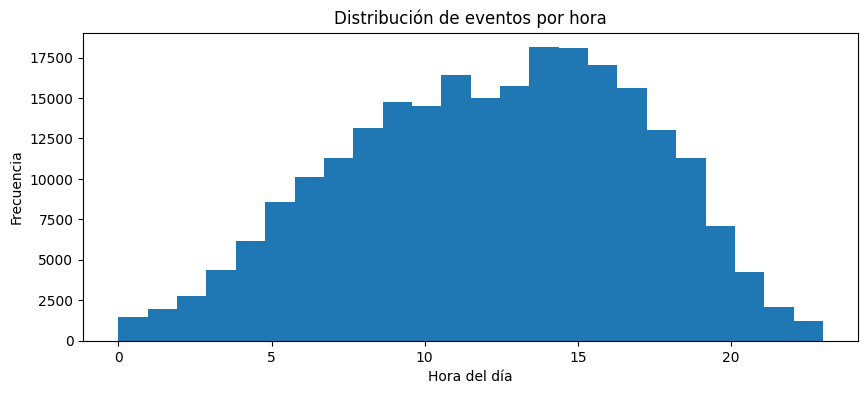

In [14]:
#Histograma por hora
empresa['hour'] = empresa['date'].dt.hour

plt.figure(figsize=(10,4))
plt.hist(empresa['hour'], bins=24)
plt.title("Distribución de eventos por hora")
plt.xlabel("Hora del día")
plt.ylabel("Frecuencia")
plt.show()

In [15]:
full_data_start = '2019-08-01'

#Eventos y usuarios totales
total_events= empresa.shape[0]
total_users = empresa['userid'].nunique()
#Eventos y usuarios despues del corte
empresa_full = empresa[empresa['date'] >= full_data_start]

full_events = empresa_full.shape[0]
full_users = empresa_full['userid'].nunique()
#Perdida de eventos y usuarios
lost_events= total_events - full_events
lost_users= total_users - full_users

#Porcentaje
lost_events_pct = lost_events / total_events * 100
lost_users_pct = lost_users / total_users * 100

print('Porcentaje de eventos perdidos:', f'{lost_events_pct:.3}')
print('='*80)
print('Porcentaje de usuarios perdidos:', f'{lost_users_pct:.3}')

Porcentaje de eventos perdidos: 1.16
Porcentaje de usuarios perdidos: 0.225


In [16]:
#Grupos Experimentales
empresa_full['exp_id'].unique()

array([246, 247, 248])

In [17]:
#Usuarios unicos por grupo
unic_user= empresa_full.groupby('exp_id')['userid'].nunique().reset_index()
unic_user

,exp_id,userid
0,246,2484
1,247,2513
2,248,2537


Después de filtrar los datos para conservar solo el periodo con información completa, se verificó la presencia de usuarios en los grupos experimentales.
Se confirmó que existen usuarios en los tres grupos (exp_id = 246, 247 y 248), y que cada grupo cuenta con una cantidad significativa de usuarios.
Por lo tanto, el experimento mantiene sus tres grupos experimentales.

### Paso 4. Estudiar el embudo de eventos

In [18]:
event_freq = (
    empresa['event']
    .value_counts()
    .reset_index()
)

event_freq.columns = ['event', 'frequency']
event_freq

,event,frequency
0,MainScreenAppear,119205
1,OffersScreenAppear,46825
2,CartScreenAppear,42731
3,PaymentScreenSuccessful,34313
4,Tutorial,1052


In [19]:
#Total de usuarios unicos
total_users

7551

In [20]:
users_per_event = empresa_full.groupby('event')['userid'].nunique().sort_values(ascending=False).reset_index()
users_per_event.columns = ['event', 'users']
users_per_event


,event,users
0,MainScreenAppear,7419
1,OffersScreenAppear,4593
2,CartScreenAppear,3734
3,PaymentScreenSuccessful,3539
4,Tutorial,840


In [21]:
#Calcular proporcion

users_per_event['proportion']= (users_per_event['users']/ total_users *100).round(3)
users_per_event


,event,users,proportion
0,MainScreenAppear,7419,98.252
1,OffersScreenAppear,4593,60.826
2,CartScreenAppear,3734,49.450
3,PaymentScreenSuccessful,3539,46.868
4,Tutorial,840,11.124


Las acciones siguen principalmente el siguiente orden: aparición de la pantalla principal, visualización de ofertas, acceso al carrito y finalización del pago. Estas acciones forman un embudo lógico de conversión. El evento Tutorial no parece formar parte de esta secuencia principal, ya que solo una pequeña proporción de usuarios lo realiza y no es un paso obligatorio para completar una compra. Por lo tanto, no es necesario incluirlo en el cálculo del embudo.

In [22]:
#Crear tabla base del embudo

funnel = users_per_event[
    users_per_event['event'].isin([
        'MainScreenAppear',
        'OffersScreenAppear',
        'CartScreenAppear',
        'PaymentScreenSuccessful'
    ])
].copy()

order = [
    'MainScreenAppear',
    'OffersScreenAppear',
    'CartScreenAppear',
    'PaymentScreenSuccessful'
]
funnel


,event,users,proportion
0,MainScreenAppear,7419,98.252
1,OffersScreenAppear,4593,60.826
2,CartScreenAppear,3734,49.450
3,PaymentScreenSuccessful,3539,46.868


In [23]:
# 1) escoger eventos del embudo
funnel = users_per_event[users_per_event['event'].isin(order)].copy()

# 2) ordenar por la secuencia del embudo
funnel['event'] = pd.Categorical(funnel['event'], categories=order, ordered=True)
funnel = funnel.sort_values('event')

# 3) conversion paso a paso
funnel['step_conversion'] = (funnel['users'] / funnel['users'].shift(1) * 100).round(2)
funnel

,event,users,proportion,step_conversion
0,MainScreenAppear,7419,98.252,NaN
1,OffersScreenAppear,4593,60.826,61.91
2,CartScreenAppear,3734,49.450,81.30
3,PaymentScreenSuccessful,3539,46.868,94.78


Aproximadamente el 61.91% de los usuarios que llegan a la pantalla principal visualizan las ofertas. De estos, alrededor del 81.30% accede al carrito, y finalmente cerca del 94.78% completa exitosamente el pago. Se observa que la mayor pérdida de usuarios ocurre en la transición entre la pantalla principal y la visualización de ofertas.

In [24]:
total_conversion = funnel.loc[
    funnel['event'] == 'PaymentScreenSuccessful', 'users'
].values[0] / funnel.loc[
    funnel['event'] == 'MainScreenAppear', 'users'
].values[0]

total_conversion * 100


47.70184661005526

Aproximadamente el 47.70% de los usuarios que inician su interacción con la aplicación completan todo el recorrido hasta realizar un pago exitoso.

### Paso 5. Estudiar los resultados del experimento

In [25]:
user_per_group= empresa.groupby('exp_id')['userid'].nunique().reset_index()
user_per_group.columns=['groups', 'users']
user_per_group

,groups,users
0,246,2489
1,247,2520
2,248,2542


In [26]:
#Crear tabla de usuarios de conversión

#crear columna binaria de pago
empresa['paid']= empresa['event'] == 'PaymentScreenSuccessful'

#Tabla de usuarios unicos
unique_users = empresa.groupby(['userid','exp_id'])['paid'].max().reset_index()
unique_users.head()

,userid,exp_id,paid
0,6888746892508752,246,False
1,6909561520679493,247,True
2,6922444491712477,246,True
3,7435777799948366,248,False
4,7702139951469979,247,True


In [27]:
#Separar los dos grupos A/A
group_246=unique_users[unique_users['exp_id']==246]['paid']
group_247=unique_users[unique_users['exp_id']==247]['paid']

In [28]:
#Prueba Estadistica
alpha= 0.05
results= st.mannwhitneyu(group_246,group_247)
# ver p-value y decidir
p_value = results.pvalue
print('p_value:',p_value)
print('')
if p_value < alpha:
    print("Hay una diferencia siginicativa entre 246 y 247")
else:
    print("No hay una diferencia siginicativa entre 246 y 247")

p_value: 0.1090633069681685

No hay una diferencia siginicativa entre 246 y 247


In [29]:
# Ver cuál es el evento más popular
empresa['event'].value_counts()

MainScreenAppear           119205
OffersScreenAppear          46825
CartScreenAppear            42731
PaymentScreenSuccessful     34313
Tutorial                     1052
Name: event, dtype: int64

In [30]:
user_events= empresa.groupby(['userid','exp_id','event']).size().reset_index(name='cnt')
user_events.head()

,userid,exp_id,event,cnt
0,6888746892508752,246,MainScreenAppear,1
1,6909561520679493,247,CartScreenAppear,1
2,6909561520679493,247,MainScreenAppear,2
3,6909561520679493,247,OffersScreenAppear,1
4,6909561520679493,247,PaymentScreenSuccessful,1


**Selecciona el evento más popular. En cada uno de los grupos de control, encuentra la cantidad de usuarios que realizaron esta acción. Encuentra su proporción. Comprueba si la diferencia entre los grupos es estadísticamente significativa. Repite el procedimiento para todos los demás eventos (ahorrarás tiempo si creas una función especial para esta prueba). ¿Puedes confirmar que los grupos se dividieron correctamente?**

In [31]:
#Crear la funcion para pobrar un evento

alpha = 0.05

def event_test(event_name):
    # filtrar solo el evento elegido (sin comillas en event_name)
    data = user_events[user_events['event'] == event_name]

    # contar si el usuario hizo el evento (1) o no (0)
    pivot = (
        data.pivot_table(
            index=['userid','exp_id'],
            values='cnt',
            aggfunc='count')
        .reset_index()
    )

    pivot['did_event'] = 1

    # lista completa de usuarios por grupo
    all_users = empresa[['userid','exp_id']].drop_duplicates()

    # unir para meter 0 a los que NO hicieron el evento
    merged = (
        all_users
        .merge(pivot[['userid','exp_id','did_event']],
               on=['userid','exp_id'],
               how='left').fillna(0)
    )

    g246 = merged[merged['exp_id'] == 246]['did_event']
    g247 = merged[merged['exp_id'] == 247]['did_event']

    pvalue = st.mannwhitneyu(g246, g247).pvalue

    prop246 = g246.mean()
    prop247 = g247.mean()

    print(f'Evento: {event_name}')
    print(f'Grupo 246: {prop246:.4f}')
    print(f'Grupo 247: {prop247:.4f}')
    print(f'p-value: {pvalue:.4f}')

    if pvalue < alpha:
        print('Diferencia significativa\n')
    else:
        print('No hay diferencia significativa\n')



In [32]:
event_test('MainScreenAppear')

Evento: MainScreenAppear
Grupo 246: 0.9867
Grupo 247: 0.9849
p-value: 0.5857
No hay diferencia significativa



In [33]:
event_test('OffersScreenAppear')

Evento: OffersScreenAppear
Grupo 246: 0.6207
Grupo 247: 0.6071
p-value: 0.3234
No hay diferencia significativa



In [34]:
event_test('CartScreenAppear')

Evento: CartScreenAppear
Grupo 246: 0.5102
Grupo 247: 0.4921
p-value: 0.1982
No hay diferencia significativa



In [35]:
event_test('PaymentScreenSuccessful')

Evento: PaymentScreenSuccessful
Grupo 246: 0.4829
Grupo 247: 0.4603
p-value: 0.1091
No hay diferencia significativa



In [36]:
event_test('Tutorial')

Evento: Tutorial
Grupo 246: 0.1121
Grupo 247: 0.1135
p-value: 0.8757
No hay diferencia significativa



**Haz lo mismo para el grupo con fuentes alteradas. Compara los resultados con los de cada uno de los grupos de control para cada evento de forma aislada. Compara los resultados con los resultados combinados de los grupos de control. ¿Qué conclusiones puedes sacar del experimento?**

In [37]:
#Preparación funcion para pobrar un evento

alpha = 0.05
def test_event_simple(event_name, g1, g2):

    data = empresa[empresa['event'] == event_name]

    pivot = (
        data
        .pivot_table(index=['userid','exp_id'], values='event', aggfunc='count')
        .reset_index()
    )

    pivot['did_event'] = 1

    all_users = empresa[['userid','exp_id']].drop_duplicates()

    merged = all_users.merge(
        pivot[['userid','exp_id','did_event']],
        on=['userid','exp_id'],
        how='left'
    ).fillna(0)

    group1 = merged[merged['exp_id'] == g1]['did_event']
    group2 = merged[merged['exp_id'] == g2]['did_event']

    pvalue = st.mannwhitneyu(group1, group2).pvalue

    print(f'\nEvento: {event_name}')
    print(f'Grupo {g1}: {group1.mean():.4f}')
    print(f'Grupo {g2}: {group2.mean():.4f}')
    print(f'p-value: {pvalue:.4f}')

    if pvalue < alpha:
        print('Diferencia ESTADÍSTICAMENTE significativa')
    else:
        print('NO hay diferencia estadísticamente significativa')


In [38]:
#Probar 248 vs cada grupo de control

events = empresa['event'].unique()

for e in events:
    test_event_simple(e, 248,246)
    test_event_simple(e, 248,247)


Evento: MainScreenAppear
Grupo 248: 0.9839
Grupo 246: 0.9867
p-value: 0.3978
NO hay diferencia estadísticamente significativa

Evento: MainScreenAppear
Grupo 248: 0.9839
Grupo 247: 0.9849
p-value: 0.7633
NO hay diferencia estadísticamente significativa

Evento: PaymentScreenSuccessful
Grupo 248: 0.4662
Grupo 246: 0.4829
p-value: 0.2341
NO hay diferencia estadísticamente significativa

Evento: PaymentScreenSuccessful
Grupo 248: 0.4662
Grupo 247: 0.4603
p-value: 0.6764
NO hay diferencia estadísticamente significativa

Evento: CartScreenAppear
Grupo 248: 0.4874
Grupo 246: 0.5102
p-value: 0.1054
NO hay diferencia estadísticamente significativa

Evento: CartScreenAppear
Grupo 248: 0.4874
Grupo 247: 0.4921
p-value: 0.7406
NO hay diferencia estadísticamente significativa

Evento: OffersScreenAppear
Grupo 248: 0.6050
Grupo 246: 0.6207
p-value: 0.2532
NO hay diferencia estadísticamente significativa

Evento: OffersScreenAppear
Grupo 248: 0.6050
Grupo 247: 0.6071
p-value: 0.8781
NO hay diferenc

In [39]:
# Crear controles combinados (246 + 247)
#Primero creamos una copia donde 246 y 247 se vuelven un solo grupo
empresa_comb = empresa.copy()
empresa_comb['exp_id'] = empresa_comb['exp_id'].replace({246: 999, 247: 999})

In [40]:
#Probamos 248 vs controles combinados:
def test_event_combined(event_name):

    data = empresa_comb[empresa_comb['event'] == event_name]

    pivot = (
        data
        .pivot_table(index=['userid','exp_id'], values='event', aggfunc='count')
        .reset_index()
    )

    pivot['did_event'] = 1

    all_users = empresa_comb[['userid','exp_id']].drop_duplicates()

    merged = all_users.merge(
        pivot[['userid','exp_id','did_event']],
        on=['userid','exp_id'],
        how='left'
    ).fillna(0)

    control = merged[merged['exp_id'] == 999]['did_event']
    test = merged[merged['exp_id'] == 248]['did_event']

    pvalue = st.mannwhitneyu(control, test).pvalue

    print(f'\nEvento: {event_name}')
    print(f'Control combinado: {control.mean():.4f}')
    print(f'Grupo 248: {test.mean():.4f}')
    print(f'p-value: {pvalue:.4f}')

    if pvalue < alpha:
        print('Diferencia ESTADÍSTICAMENTE significativa')
    else:
        print('NO hay diferencia estadísticamente significativa')


In [41]:
for e in events:
    test_event_combined(e)



Evento: MainScreenAppear
Control combinado: 0.9858
Grupo 248: 0.9839
p-value: 0.5068
NO hay diferencia estadísticamente significativa

Evento: PaymentScreenSuccessful
Control combinado: 0.4716
Grupo 248: 0.4662
p-value: 0.6579
NO hay diferencia estadísticamente significativa

Evento: CartScreenAppear
Control combinado: 0.5011
Grupo 248: 0.4874
p-value: 0.2610
NO hay diferencia estadísticamente significativa

Evento: OffersScreenAppear
Control combinado: 0.6139
Grupo 248: 0.6050
p-value: 0.4556
NO hay diferencia estadísticamente significativa

Evento: Tutorial
Control combinado: 0.1128
Grupo 248: 0.1109
p-value: 0.8087
NO hay diferencia estadísticamente significativa


Conclusiones: Se comparó el grupo experimental (248) con cada grupo de control (246 y 247) por separado y con los grupos de control combinados para cada evento del funnel.

En la mayoría de los eventos, los p-values fueron mayores a 0.05, lo que indica que no se encontraron diferencias estadísticamente significativas entre el grupo con fuentes alteradas y los grupos de control.

Esto sugiere que el cambio de fuentes no tuvo un impacto significativo en el comportamiento de los usuarios ni en las conversiones del embudo.

Dado que los grupos de control tampoco presentan diferencias entre sí, se confirma que el experimento fue correctamente dividido y los resultados son confiables.

**¿Qué nivel de significancia has establecido para probar las hipótesis estadísticas mencionadas anteriormente? Calcula cuántas pruebas de hipótesis estadísticas has realizado. Con un nivel de significancia estadística de 0.1, uno de cada 10 resultados podría ser falso. ¿Cuál debería ser el nivel de significancia? Si deseas cambiarlo, vuelve a ejecutar los pasos anteriores y comprueba tus conclusiones.**

Se estableció un nivel de significancia estadística de α = 0.05 para probar las hipótesis.

Se realizaron 20 (5 eventos * 4 comparaciones) pruebas estadísticas en total, correspondientes a la comparación de varios eventos entre los grupos experimentales (pruebas A/A y A/B).

Si se utilizara un nivel de significancia de 0.1, aproximadamente 1 de cada 10 resultados podría ser un falso positivo. Dado que se realizaron múltiples pruebas, la probabilidad de obtener resultados significativos por azar aumenta.

Por esta razón, un nivel de significancia de 0.05 es más apropiado. Incluso aplicando una corrección por múltiples pruebas (por ejemplo, Bonferroni), las conclusiones no cambian: no se encontraron diferencias estadísticamente significativas consistentes entre el grupo experimental y los grupos de control.


Por lo tanto, se concluye que
 el cambio en las fuentes no tuvo un impacto estadísticamente significativo en el comportamiento de los usuarios.